In [1]:
# ============================================================
# CELL 1: SETUP + INSTALL MEDICAL MODELS
# ============================================================

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Install medical model dependencies
for pkg in ["open_clip_torch", "transformers", "timm"]:
    try:
        __import__(pkg.replace("-", "_").split("_")[0])
    except ImportError:
        print(f"Installing {pkg}...")
        install(pkg)

import os, re, cv2, copy, time, random, gc, math, hashlib, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from collections import Counter, defaultdict
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    confusion_matrix, classification_report
)
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
USE_AMP = torch.cuda.is_available()

def seed_everything(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = True

seed_everything(SEED)
print(f"Device: {DEVICE} | AMP: {USE_AMP}")

Installing open_clip_torch...
Installing transformers...
Device: cuda | AMP: True


In [2]:
# ============================================================
# CELL 2: CONFIGURATION (streamlined for speed)
# ============================================================

class CFG:
    data_root      = "/teamspace/studios/this_studio/EndoscopicBladderTissue"
    aug_root       = "/teamspace/studios/this_studio/Augmented Data"
    aug_manifest   = "/teamspace/studios/this_studio/Augmented Data/augmented_only_manifest.csv"
    cache_dir_orig = "feature_cache_med_orig"
    cache_dir_aug  = "feature_cache_med_aug"
    cache_version  = "med_v1"

    class_names   = ['HGC', 'LGC', 'Normal']
    num_classes   = 3

    image_resize          = 512
    clahe_clip            = 1.5
    clahe_grid            = (16, 16)
    patch_scales          = [96, 128, 192]
    patch_output_size     = 224
    patch_stride_frac     = 0.5
    min_tissue            = 0.40
    max_bright            = 245
    min_bright            = 15
    min_sat               = 10
    min_focus             = 8.0
    top_quality_frac      = 0.85
    max_patches_per_image = 45          # ← reduced for speed

    feat_batch    = 48                  # ← tuned for T4 memory
    feat_dim      = 1024                # updated after backbone load

    # CLAM (simplified — let features do the work)
    mil_hidden      = 384
    mil_dropout     = 0.25
    clam_k_sample   = 8
    feat_noise_std  = 0.02
    feat_drop_p     = 0.1
    n_att_heads     = 4

    # Losses
    bag_loss_w       = 1.0
    inst_loss_w      = 0.15
    hier_loss_w      = 0.10
    ordinal_loss_w   = 0.08
    focal_gamma      = 2.5
    hgc_weight_boost = 1.8
    label_smooth     = 0.05
    misclass_cost    = [
        [0.0, 1.8, 2.5],
        [1.3, 0.0, 2.0],
        [0.8, 0.4, 0.0],
    ]
    misclass_loss_w  = 0.12

    # MixUp
    mixup_alpha     = 0.3
    mixup_prob      = 0.20
    mixup_cap_frac  = 0.12

    balanced_sampling = True

    # Training (no stage 2 — simpler, faster)
    epochs           = 45
    patience         = 10
    lr               = 8e-5
    wd               = 5e-5
    grad_clip        = 1.0
    warmup_epochs    = 3
    max_patches_train = 150
    max_patches_test  = 300

    # Ensemble
    n_ensemble         = 3
    ensemble_dropouts  = [0.20, 0.25, 0.30]
    use_tta            = True
    tta_rounds         = 3
    use_mc_dropout     = True

    optimize_thresholds = True
    recall_priority     = 1.5

    class_weights = None

IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(DEVICE)
IMNET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(DEVICE)
LABEL_MAP  = {'HGC': 'HGC', 'LGC': 'LGC', 'NST': 'Normal', 'NTL': 'Normal'}
CANCER_CLASSES = {0, 1}

os.makedirs(CFG.cache_dir_orig, exist_ok=True)
os.makedirs(CFG.cache_dir_aug,  exist_ok=True)
print("✓ Config loaded (medical backbone edition)")

✓ Config loaded (medical backbone edition)


In [3]:
# ============================================================
# CELL 3: LOAD ORIGINAL DATASET
# ============================================================

records = []
pattern = re.compile(r'pt[_]?0*(\d+)')
for label in os.listdir(CFG.data_root):
    cp = os.path.join(CFG.data_root, label)
    if not os.path.isdir(cp) or label not in LABEL_MAP: continue
    for img_name in os.listdir(cp):
        m = pattern.search(img_name)
        if m:
            records.append({"path": os.path.join(cp, img_name),
                "label": LABEL_MAP[label], "original_label": label,
                "patient": int(m.group(1)), "filename": img_name,
                "is_augmented": False, "aug_mode": "none"})

df = pd.DataFrame(records)
class_to_idx = {c: i for i, c in enumerate(CFG.class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df["target"] = df["label"].map(class_to_idx)
EXPECTED_TOTAL = len(df)

class_counts = df['label'].value_counts()
total = len(df)
PATIENTS   = sorted(df.patient.unique())
N_PATIENTS = len(PATIENTS)

print(f"✓ {EXPECTED_TOTAL} images, {N_PATIENTS} patients")
for cls in CFG.class_names:
    n = class_counts.get(cls, 0)
    print(f"  {cls}: {n} ({100*n/total:.1f}%)")

✓ 1607 images, 14 patients
  HGC: 426 (26.5%)
  LGC: 595 (37.0%)
  Normal: 586 (36.5%)


In [4]:
# ============================================================
# CELL 4: LOAD AUGMENTED DATASET
# ============================================================

aug_df = pd.read_csv(CFG.aug_manifest)
aug_file_index = {}
for root, dirs, files in os.walk(CFG.aug_root):
    for fname in files:
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            aug_file_index[fname] = os.path.join(root, fname)

FNAME_COL = None
for c in ['HLY', 'filename', 'aug_filename', 'file']:
    if c in aug_df.columns: FNAME_COL = c; break
if FNAME_COL is None:
    for c in aug_df.columns:
        if str(aug_df[c].iloc[0]).strip().endswith(('.png','.jpg','.jpeg')):
            FNAME_COL = c; break
if FNAME_COL is None:
    raise ValueError(f"No filename col. Cols: {aug_df.columns.tolist()}")

def resolve_aug_path(f):
    f = str(f).strip()
    if f in aug_file_index: return aug_file_index[f]
    b = os.path.basename(f)
    if b in aug_file_index: return aug_file_index[b]
    return None

aug_df['path'] = aug_df[FNAME_COL].apply(resolve_aug_path)
aug_df = aug_df[aug_df['path'].notna()].reset_index(drop=True)
aug_df['label'] = aug_df['tissue type'].map(LABEL_MAP)
aug_df = aug_df[aug_df['label'].notna()].copy()
aug_df['target'] = aug_df['label'].map(class_to_idx)
aug_df['is_augmented'] = True
if 'patient_id' in aug_df.columns:
    aug_df = aug_df.rename(columns={'patient_id': 'patient'})
aug_df['patient'] = aug_df['patient'].astype(int)

print(f"✓ {len(aug_df)} augmented images")
for cls in CFG.class_names:
    print(f"  {cls}: {(aug_df['label']==cls).sum()}")

✓ 1588 augmented images
  HGC: 445
  LGC: 604
  Normal: 539


In [5]:
# ============================================================
# CELL 5: CLASS WEIGHTS
# ============================================================

weights = []
for cls in CFG.class_names:
    count = class_counts.get(cls, 0)
    w = total / (CFG.num_classes * max(count, 1))
    if cls == 'HGC': w *= CFG.hgc_weight_boost
    weights.append(w)
    print(f"  {cls}: weight={w:.3f}")
CFG.class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

  HGC: weight=2.263
  LGC: weight=0.900
  Normal: weight=0.914


In [6]:
# ============================================================
# CELL 6: LAB NORMALIZER + CLAHE + PATCH EXTRACTION
# ============================================================

class LabNormalizer:
    def __init__(self): self.ref = None
    def fit(self, images_bgr):
        stats = {'L':[],'a':[],'b':[]}
        for img in images_bgr:
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
            for i, ch in enumerate(['L','a','b']):
                stats[ch].append({'m':lab[:,:,i].mean(),'s':lab[:,:,i].std()+1e-6})
        self.ref = {ch:{'m':np.median([s['m'] for s in stats[ch]]),
                        's':np.median([s['s'] for s in stats[ch]])} for ch in ['L','a','b']}
        return self
    def transform(self, img_bgr):
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
        for i, ch in enumerate(['L','a','b']):
            c=lab[:,:,i]; sm,ss=c.mean(),c.std()+1e-6
            lab[:,:,i]=np.clip((c-sm)*(self.ref[ch]['s']/ss)+self.ref[ch]['m'],0,255)
        lab=lab.astype(np.uint8)
        clahe=cv2.createCLAHE(clipLimit=CFG.clahe_clip,tileGridSize=CFG.clahe_grid)
        lab[:,:,0]=clahe.apply(lab[:,:,0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def load_image(path, norm=None):
    img=cv2.imread(path)
    if img is None: raise FileNotFoundError(path)
    h,w=img.shape[:2]; s=CFG.image_resize/max(h,w)
    if s!=1: img=cv2.resize(img,(int(w*s),int(h*s)),interpolation=cv2.INTER_AREA)
    if norm: img=norm.transform(img)
    return img

def fit_normalizer_excluding(exclude_pid=None):
    samples=[]
    for pid in PATIENTS:
        if pid==exclude_pid: continue
        for fp in df[df.patient==pid].path.values[:12]:
            try:
                img=cv2.imread(fp)
                if img is not None:
                    h,w=img.shape[:2]; s=CFG.image_resize/max(h,w)
                    if s!=1: img=cv2.resize(img,(int(w*s),int(h*s)))
                    samples.append(img)
            except: pass
    return LabNormalizer().fit(samples)

def compute_quality(p):
    hsv=cv2.cvtColor(p,cv2.COLOR_BGR2HSV)
    v=hsv[:,:,2].astype(np.float32); s=hsv[:,:,1].astype(np.float32)
    mask=(v<CFG.max_bright)&(v>CFG.min_bright)&(s>CFG.min_sat)
    tf=mask.sum()/mask.size
    if tf<CFG.min_tissue: return -1.0
    gray=cv2.cvtColor(p,cv2.COLOR_BGR2GRAY)
    focus=cv2.Laplacian(gray,cv2.CV_64F).var()
    if focus<CFG.min_focus: return -1.0
    fn=min(focus/100,1.0); sn=min((s[mask].std()/50 if mask.sum()>10 else 0),1.0)
    ed=min(cv2.Canny(gray,50,150).sum()/(255*gray.size)*10,1.0)
    return 0.3*tf+0.3*fn+0.2*sn+0.2*ed

def extract_multiscale_patches(img, max_p=None):
    if max_p is None: max_p=CFG.max_patches_per_image
    H,W=img.shape[:2]; cands=[]; cap=max_p*3
    for sc in CFG.patch_scales:
        if sc>min(H,W): continue
        st=max(1,int(sc*CFG.patch_stride_frac))
        for y in range(0,H-sc+1,st):
            for x in range(0,W-sc+1,st):
                if len(cands)>=cap: break
                crop=img[y:y+sc,x:x+sc]; q=compute_quality(crop)
                if q>0:
                    cands.append((cv2.resize(crop,(CFG.patch_output_size,CFG.patch_output_size),
                                  interpolation=cv2.INTER_AREA),q,sc))
            if len(cands)>=cap: break
    if not cands: return [],[],[]
    cands.sort(key=lambda x:x[1],reverse=True)
    n=max(1,int(len(cands)*CFG.top_quality_frac))
    cands=cands[:n][:max_p]
    return [c[0] for c in cands],[c[1] for c in cands],[c[2] for c in cands]

global_normalizer = fit_normalizer_excluding(exclude_pid=None)
print("✓ Normalizer + patch extraction ready")

✓ Normalizer + patch extraction ready


In [7]:
# ============================================================
# CELL 7: MEDICAL BACKBONES (BiomedCLIP + Phikon + fallbacks)
# ============================================================

loaded_backbones = {}

# ── 1. BiomedCLIP (Microsoft — trained on 15M biomedical images) ──
def load_biomedclip():
    try:
        import open_clip
        model, _, preprocess = open_clip.create_model_and_transforms(
            'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
        )
        # We only need the visual encoder
        visual = model.visual
        visual.eval()
        for p in visual.parameters(): p.requires_grad = False

        # Test forward pass to get dimension
        dummy = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            out = visual(dummy)
        dim = out.shape[-1]
        print(f"  ✓ BiomedCLIP — dim={dim}")
        return visual.to(DEVICE), dim
    except Exception as e:
        print(f"  ⚠ BiomedCLIP failed: {e}")
        return None, 0

# ── 2. Phikon (Owkin — trained on TCGA pathology WSIs) ──
def load_phikon():
    try:
        from transformers import AutoModel
        model = AutoModel.from_pretrained("owkin/phikon", trust_remote_code=True)
        model.eval()
        for p in model.parameters(): p.requires_grad = False

        # Test
        dummy = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            out = model(dummy)
            if hasattr(out, 'last_hidden_state'):
                feat = out.last_hidden_state[:, 0, :]
            elif hasattr(out, 'pooler_output'):
                feat = out.pooler_output
            else:
                feat = out[0][:, 0, :]
        dim = feat.shape[-1]
        print(f"  ✓ Phikon — dim={dim}")
        return model.to(DEVICE), dim
    except Exception as e:
        print(f"  ⚠ Phikon failed: {e}")
        return None, 0

# ── 3. DINOv2 fallback ──
def load_dinov2():
    for mn, dim in [('dinov2_vitb14', 768), ('dinov2_vits14', 384)]:
        try:
            m = torch.hub.load('facebookresearch/dinov2', mn)
            m.eval()
            for p in m.parameters(): p.requires_grad = False
            print(f"  ✓ {mn} (fallback) — dim={dim}")
            return m.to(DEVICE), dim
        except: pass
    return None, 0

# ── 4. DenseNet121 fallback ──
def load_densenet():
    m = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    fd = m.classifier.in_features; m.classifier = nn.Identity()
    m.eval()
    for p in m.parameters(): p.requires_grad = False
    print(f"  ✓ DenseNet121 (fallback) — dim={fd}")
    return m.to(DEVICE), fd

# ── Load in priority order ──
print("Loading medical backbones...")
print("="*50)

backbone_models = []
backbone_names  = []
total_dim       = 0

# Priority 1: BiomedCLIP
bc_model, bc_dim = load_biomedclip()
if bc_model:
    backbone_models.append(('biomedclip', bc_model, bc_dim))
    backbone_names.append(f"BiomedCLIP({bc_dim})")
    total_dim += bc_dim

# Priority 2: Phikon
ph_model, ph_dim = load_phikon()
if ph_model:
    backbone_models.append(('phikon', ph_model, ph_dim))
    backbone_names.append(f"Phikon({ph_dim})")
    total_dim += ph_dim

# Fallback: DINOv2 (if neither medical model loaded)
if total_dim == 0:
    print("\n  ⚠ No medical models available — using DINOv2 + DenseNet fallback")
    d2_model, d2_dim = load_dinov2()
    if d2_model:
        backbone_models.append(('dinov2', d2_model, d2_dim))
        backbone_names.append(f"DINOv2({d2_dim})")
        total_dim += d2_dim

# Always add DenseNet as complementary features
dn_model, dn_dim = load_densenet()
backbone_models.append(('densenet', dn_model, dn_dim))
backbone_names.append(f"DenseNet121({dn_dim})")
total_dim += dn_dim

CFG.feat_dim = total_dim
backbone_desc = " + ".join(backbone_names)
print(f"\n✓ Total feature dim: {CFG.feat_dim}")
print(f"✓ Backbone: {backbone_desc}")

# Verify
print(f"\nLoaded {len(backbone_models)} backbones:")
for name, model, dim in backbone_models:
    print(f"  {name}: dim={dim}")

Loading medical backbones...


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

  ✓ BiomedCLIP — dim=512


config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

  ✓ Phikon — dim=768
  ✓ DenseNet121 (fallback) — dim=1024

✓ Total feature dim: 2304
✓ Backbone: BiomedCLIP(512) + Phikon(768) + DenseNet121(1024)

Loaded 3 backbones:
  biomedclip: dim=512
  phikon: dim=768
  densenet: dim=1024


In [8]:
# ============================================================
# CELL 8: FEATURE EXTRACTION (medical backbones)
# ============================================================

def bgr_to_tensor(p):
    return torch.from_numpy(cv2.cvtColor(p, cv2.COLOR_BGR2RGB)).permute(2,0,1).float()/255.0

def _get_cache_key(path, is_aug):
    k = f"{'AUG' if is_aug else 'ORIG'}|{path}|{CFG.patch_scales}|{CFG.max_patches_per_image}|{CFG.cache_version}"
    return hashlib.md5(k.encode()).hexdigest()

@torch.no_grad()
def extract_medical_features(tensor_list):
    """Extract features from all loaded backbones."""
    all_feats = []
    for i in range(0, len(tensor_list), CFG.feat_batch):
        batch = torch.stack(tensor_list[i:i+CFG.feat_batch]).to(DEVICE)
        batch_norm = (batch - IMNET_MEAN) / IMNET_STD
        parts = []

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            for name, model, dim in backbone_models:
                if name == 'biomedclip':
                    out = model(batch_norm)
                    if out.dim() > 2: out = out[:, 0, :]
                    parts.append(out.float().cpu())

                elif name == 'phikon':
                    out = model(batch_norm)
                    if hasattr(out, 'last_hidden_state'):
                        feat = out.last_hidden_state[:, 0, :]
                    elif hasattr(out, 'pooler_output') and out.pooler_output is not None:
                        feat = out.pooler_output
                    else:
                        feat = out[0][:, 0, :]
                    parts.append(feat.float().cpu())

                elif name == 'dinov2':
                    out = model(batch_norm)
                    if isinstance(out, dict):
                        feat = out.get('x_norm_clstoken', next(iter(out.values())))
                    else:
                        feat = out
                    if feat.dim() > 2: feat = feat[:, 0, :]
                    parts.append(feat.float().cpu())

                elif name == 'densenet':
                    parts.append(model(batch_norm).float().cpu())

        all_feats.append(torch.cat(parts, dim=1))
    return torch.cat(all_feats, 0).half()


def extract_features_for_rows(row_df, desc="Ext", norm=None, is_augmented=False):
    cd = CFG.cache_dir_aug if is_augmented else CFG.cache_dir_orig
    results, skipped, ch = [], 0, 0
    for _, row in tqdm(row_df.iterrows(), total=len(row_df), desc=desc):
        cp = os.path.join(cd, f"{_get_cache_key(row.path, is_augmented)}.pt")
        if os.path.exists(cp):
            try:
                c = torch.load(cp, map_location='cpu')
                # Verify cached features match expected dim
                if c['features'].shape[1] == CFG.feat_dim:
                    results.append({'features':c['features'],'label':int(row.target),
                        'label_name':row.label,'patient':int(row.patient),'path':row.path,
                        'is_augmented':is_augmented,'aug_mode':str(row.get('aug_mode','none')),
                        'n_patches':c['features'].shape[0]}); ch+=1; continue
            except: pass
        try: img = load_image(row.path, norm)
        except: skipped+=1; continue
        patches,_,_ = extract_multiscale_patches(img)
        if not patches: skipped+=1; continue
        tensors = [bgr_to_tensor(p) for p in patches]
        if len(tensors)>CFG.max_patches_per_image:
            idx=random.sample(range(len(tensors)),CFG.max_patches_per_image)
            tensors=[tensors[i] for i in sorted(idx)]
        feats = extract_medical_features(tensors)
        torch.save({'features':feats}, cp)
        results.append({'features':feats,'label':int(row.target),'label_name':row.label,
            'patient':int(row.patient),'path':row.path,'is_augmented':is_augmented,
            'aug_mode':str(row.get('aug_mode','none')),'n_patches':feats.shape[0]})
    if skipped: print(f"  ⚠ Skipped {skipped}")
    if ch: print(f"  ⚡ Cache: {ch}/{len(row_df)}")
    return results

print("\nExtracting features with MEDICAL backbones...")
t0 = time.time()
orig_image_data = extract_features_for_rows(df, "Original", global_normalizer, False)
print(f"✓ {len(orig_image_data)} original | {(time.time()-t0)/60:.1f} min")

t0 = time.time()
aug_image_data = extract_features_for_rows(aug_df, "Augmented", global_normalizer, True)
print(f"✓ {len(aug_image_data)} augmented | {(time.time()-t0)/60:.1f} min")

# Integrity
orig_image_data = [d for d in orig_image_data if not d['is_augmented']]
aug_image_data  = [d for d in aug_image_data  if d['is_augmented']]
print(f"\n✓ {len(orig_image_data)} orig, {len(aug_image_data)} aug (verified)")

# Free backbones
for name, model, dim in backbone_models: del model
backbone_models = []
torch.cuda.empty_cache(); gc.collect()
print("✓ Backbones freed")


Extracting features with MEDICAL backbones...


Original:   0%|          | 0/1607 [00:00<?, ?it/s]/tmp/ipykernel_6673/2155846607.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
Original: 100%|██████████| 1607/1607 [11:18<00:00,  2.37it/s]


✓ 1607 original | 11.3 min


Augmented:   0%|          | 0/1588 [00:00<?, ?it/s]/tmp/ipykernel_6673/2155846607.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
Augmented: 100%|██████████| 1588/1588 [11:00<00:00,  2.41it/s]


✓ 1588 augmented | 11.0 min

✓ 1607 orig, 1588 aug (verified)
✓ Backbones freed


In [9]:
# ============================================================
# CELL 9: LOSSES (focal + hier + ordinal + asymmetric)
# ============================================================

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma=gamma; self.weight=weight; self.ls=label_smoothing
    def forward(self, logits, targets):
        ce=F.cross_entropy(logits,targets,weight=self.weight,label_smoothing=self.ls,reduction='none')
        return (((1-torch.exp(-ce))**self.gamma)*ce).mean()

def hierarchical_loss(logits, label):
    bl = torch.stack([logits[0]+logits[1], logits[2]]).unsqueeze(0)
    bt = torch.tensor([0 if label.item() in CANCER_CLASSES else 1],
                      dtype=torch.long, device=label.device)
    return F.cross_entropy(bl, bt)

def ordinal_loss(logits, label):
    p=F.softmax(logits,dim=0)
    s=torch.arange(CFG.num_classes,dtype=torch.float32,device=logits.device)
    return ((p*s).sum()-s[label])**2

def asymmetric_cost_loss(logits, label):
    p=F.softmax(logits,dim=0)
    c=torch.tensor(CFG.misclass_cost[label.item()],dtype=torch.float32,device=logits.device)
    return (p*c).sum()

def compute_loss(output, label, cw=None, fc=None):
    lo=output['logits'].unsqueeze(0); ta=label.unsqueeze(0)
    bag = fc(lo,ta) if fc else F.cross_entropy(lo,ta,weight=cw,label_smoothing=CFG.label_smooth)
    return (CFG.bag_loss_w*bag + CFG.hier_loss_w*hierarchical_loss(output['logits'],label) +
            CFG.ordinal_loss_w*ordinal_loss(output['logits'],label) +
            CFG.misclass_loss_w*asymmetric_cost_loss(output['logits'],label) +
            CFG.inst_loss_w*output['inst_loss'])

print("✓ Loss functions ready")

✓ Loss functions ready


In [10]:
# ============================================================
# CELL 10: CLAM MODEL (clean, effective)
# ============================================================

class MultiHeadGatedAttention(nn.Module):
    def __init__(self, hidden, n_heads=4):
        super().__init__()
        self.hd = hidden//2//n_heads
        self.att = nn.ModuleList([nn.Sequential(nn.Linear(hidden,self.hd),nn.Tanh()) for _ in range(n_heads)])
        self.gate = nn.ModuleList([nn.Sequential(nn.Linear(hidden,self.hd),nn.Sigmoid()) for _ in range(n_heads)])
        self.comb = nn.Linear(self.hd*n_heads, hidden//2)
    def forward(self, h):
        return self.comb(torch.cat([a(h)*g(h) for a,g in zip(self.att,self.gate)], dim=-1))

class CLAM(nn.Module):
    def __init__(self, feat_dim=CFG.feat_dim, hidden=CFG.mil_hidden,
                 n_classes=CFG.num_classes, dropout=CFG.mil_dropout,
                 k_sample=CFG.clam_k_sample):
        super().__init__()
        self.n_classes=n_classes; self.k_sample=k_sample
        self.feat_noise=CFG.feat_noise_std
        self.feat_drop=nn.Dropout(CFG.feat_drop_p)

        self.fc = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.LayerNorm(hidden),
            nn.GELU(), nn.Dropout(dropout))
        self.mh_att = MultiHeadGatedAttention(hidden, CFG.n_att_heads)
        self.att_temp = nn.Parameter(torch.ones(n_classes))
        self.att_br = nn.ModuleList([nn.Linear(hidden//2,1) for _ in range(n_classes)])
        self.inst_cl = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden,96),nn.GELU(),nn.Linear(96,2))
            for _ in range(n_classes)])
        self.bag_cl = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden,hidden//4),nn.GELU(),nn.Linear(hidden//4,1))
            for _ in range(n_classes)])

    def _inst_loss(self, scores, h, clf, k):
        N=scores.shape[0]; k=min(k,N//2,8)
        if k<1: return torch.tensor(0.0,device=h.device)
        ti=torch.topk(scores,k).indices; bi=torch.topk(scores,k,largest=False).indices
        f=torch.cat([h[ti],h[bi]]); l=torch.cat([torch.ones(k),torch.zeros(k)]).long().to(h.device)
        return F.cross_entropy(clf(f),l)

    def forward(self, x, label=None):
        x=x.float()
        if self.training:
            x=x+torch.randn_like(x)*self.feat_noise; x=self.feat_drop(x)
        h=self.fc(x); att=self.mh_att(h)
        logits=[]; ti=torch.tensor(0.0,device=x.device)
        for c in range(self.n_classes):
            a_s=self.att_br[c](att).squeeze(-1)/(self.att_temp[c].abs()+0.1)
            a_w=F.softmax(a_s,dim=0)
            bag=torch.sum(a_w.unsqueeze(-1)*h,dim=0)
            logits.append(self.bag_cl[c](bag))
            if self.training and label is not None and label.item()==c:
                ti+=self._inst_loss(a_s.detach(),h,self.inst_cl[c],self.k_sample)
        return {'logits':torch.cat(logits),'inst_loss':ti}

_m=CLAM().to(DEVICE); _x=torch.randn(20,CFG.feat_dim).to(DEVICE)
_m.train(); _o=_m(_x,label=torch.tensor(0).to(DEVICE))
print(f"✓ CLAM: feat_dim={CFG.feat_dim} → logits {_o['logits'].shape} | "
      f"Params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m,_x,_o; torch.cuda.empty_cache()

✓ CLAM: feat_dim=2304 → logits torch.Size([3]) | Params: 1,293,999


In [11]:
# ============================================================
# CELL 11: TRAINING + PREDICTION
# ============================================================

def feature_mixup(dl, alpha=CFG.mixup_alpha):
    bc=defaultdict(list)
    for d in dl: bc[d['label']].append(d)
    mx=[]
    for cls,items in bc.items():
        if len(items)<2: continue
        nm = len(items) if cls==0 else len(items)//2
        for _ in range(nm):
            if random.random()>CFG.mixup_prob: continue
            i,j=random.sample(range(len(items)),2); lam=np.random.beta(alpha,alpha)
            f1,f2=items[i]['features'],items[j]['features']
            mn=min(f1.shape[0],f2.shape[0])
            mf=lam*f1[torch.randperm(f1.shape[0])[:mn]]+(1-lam)*f2[torch.randperm(f2.shape[0])[:mn]]
            mx.append({'features':mf,'label':cls,'label_name':items[i]['label_name'],
                'patient':items[i]['patient'],'path':'mixup','is_augmented':True,
                'aug_mode':'mixup','n_patches':mf.shape[0]})
    return mx

def class_balanced_sample(dl):
    bc=defaultdict(list)
    for d in dl: bc[d['label']].append(d)
    mx=max(len(v) for v in bc.values()); bal=[]
    for cls,items in bc.items():
        bal.extend(items)
        if len(items)<mx: bal.extend(random.choices(items,k=mx-len(items)))
    random.shuffle(bal); return bal

def get_scheduler(opt, warmup, total):
    def lr_lambda(e):
        if e<warmup: return (e+1)/warmup
        return 0.5*(1+math.cos(math.pi*(e-warmup)/max(total-warmup,1)))
    return torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

def train_clam(model, train_imgs, val_imgs=None, epochs=CFG.epochs,
               cw=None, drop_override=None, verbose=False):
    model.train()
    if drop_override:
        for m in model.modules():
            if isinstance(m,nn.Dropout): m.p=drop_override

    fc=FocalLoss(gamma=CFG.focal_gamma,weight=cw,label_smoothing=CFG.label_smooth).to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=CFG.lr,weight_decay=CFG.wd)
    sch=get_scheduler(opt,CFG.warmup_epochs,epochs)
    scaler=torch.cuda.amp.GradScaler(enabled=USE_AMP)

    bvl=float('inf'); bst=None; pc=0
    mx_s=feature_mixup(train_imgs)
    mx_cap=max(1,int(len(train_imgs)*CFG.mixup_cap_frac))

    for ep in range(epochs):
        model.train()
        ed=class_balanced_sample(train_imgs) if CFG.balanced_sampling else train_imgs.copy()
        if mx_s: ed.extend(random.sample(mx_s,min(len(mx_s),mx_cap)))
        random.shuffle(ed); el=0.0

        for d in ed:
            f=d['features'].to(DEVICE); l=torch.tensor(d['label'],dtype=torch.long).to(DEVICE)
            if f.shape[0]>CFG.max_patches_train: f=f[torch.randperm(f.shape[0])[:CFG.max_patches_train]]
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                o=model(f,label=l); loss=compute_loss(o,l,cw,fc)
            opt.zero_grad(set_to_none=True); scaler.scale(loss).backward()
            scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(),CFG.grad_clip)
            scaler.step(opt); scaler.update(); el+=loss.item()
        sch.step()

        if val_imgs:
            model.eval(); vl=0.0
            with torch.no_grad():
                for d in val_imgs:
                    f=d['features'].to(DEVICE); l=torch.tensor(d['label'],dtype=torch.long).to(DEVICE)
                    if f.shape[0]>CFG.max_patches_test: f=f[torch.randperm(f.shape[0])[:CFG.max_patches_test]]
                    with torch.cuda.amp.autocast(enabled=USE_AMP):
                        o=model(f,label=l); vl+=compute_loss(o,l,cw,fc).item()
            av=vl/max(len(val_imgs),1)
            if av<bvl: bvl=av; bst=copy.deepcopy(model.state_dict()); pc=0
            else: pc+=1
            if pc>=CFG.patience:
                if verbose: print(f"    Stop ep{ep+1}"); break
            if verbose and (ep+1)%15==0: print(f"    Ep{ep+1} t={el/len(ed):.4f} v={av:.4f}")

    if bst: model.load_state_dict(bst)
    return model

@torch.no_grad()
def predict_probs(model, feats, use_mc=False):
    if use_mc: model.train()
    else: model.eval()
    feats=feats.to(DEVICE)
    if feats.shape[0]>CFG.max_patches_test: feats=feats[torch.randperm(feats.shape[0])[:CFG.max_patches_test]]
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        o=model(feats)
    return F.softmax(o['logits'].float(),dim=0).cpu().numpy()

def ensemble_probs(models, feats, use_tta=False):
    ap=[]; ae=[]
    for m in models:
        mp=[predict_probs(m,feats,False)]
        if CFG.use_mc_dropout:
            for _ in range(2): mp.append(predict_probs(m,feats,True))
        if use_tta and CFG.use_tta:
            for _ in range(CFG.tta_rounds): mp.append(predict_probs(m,feats,False))
        avg=np.mean(mp,0); avg=avg/(avg.sum()+1e-8)
        ap.append(avg); ae.append(-np.sum(avg*np.log(avg+1e-8)))
    ap=np.array(ap); ae=np.array(ae)
    w=1.0/(ae+0.1); w=w/w.sum()
    geo=np.exp(np.sum(np.log(ap+1e-8)*w[:,None],0))
    geo=geo/geo.sum()
    return geo

def optimize_thresholds(vt, vp, nc=3):
    vt=np.array(vt); vp=np.array(vp)
    if len(vt)<5: return np.ones(nc)
    def obj(mult):
        adj=vp*mult; preds=adj.argmax(1)
        recs=[((preds[vt==c]==c).mean() if (vt==c).sum()>0 else 1.0) for c in range(nc)]
        return -(CFG.recall_priority*np.mean(recs)+min(recs))
    res=minimize(obj,np.ones(nc),method='Nelder-Mead',options={'maxiter':500})
    t=res.x; return t/t.max()

print("✓ Training + prediction ready")

✓ Training + prediction ready


In [12]:
# ============================================================
# CELL 12 (COMPLETE): LOPO ENGINE
# ============================================================

def fold_weights(ti):
    c=Counter(d['label'] for d in ti); tn=sum(c.values())
    w=torch.zeros(CFG.num_classes)
    for k in range(CFG.num_classes): w[k]=tn/(CFG.num_classes*max(c.get(k,0),1))
    w[class_to_idx['HGC']]*=CFG.hgc_weight_boost
    return w.to(DEVICE)

def val_split(ti):
    orig=[d for d in ti if not d['is_augmented']]; aug=[d for d in ti if d['is_augmented']]
    pg=defaultdict(list)
    for d in orig: pg[d['patient']].append(d)
    pts=list(pg.keys())
    if len(pts)<3: return ti,[]
    nv=2 if len(pts)>=8 else 1
    ps=sorted([(p,len(i)) for p,i in pg.items()],key=lambda x:x[1])
    mid=len(ps)//2; vp=[ps[mid-i][0] for i in range(nv)]
    vi=[]; [vi.extend(pg[p]) for p in vp]
    return ([d for d in orig if d['patient'] not in vp] +
            [d for d in aug if d['patient'] not in vp]), vi

def run_lopo(orig_data, aug_data):
    tag = f"MEDICAL BACKBONE ({backbone_desc})"
    print(f"\n{'='*60}")
    print(f"  LOPO: {tag}")
    print(f"  {N_PATIENTS} folds × {CFG.n_ensemble} seeds")
    print(f"{'='*60}\n")

    orig_only = [d for d in orig_data if not d['is_augmented']]
    fold_results = []
    yt_img = []; yp_img_raw = []; yp_img_thr = []
    yt_pat = []; yp_pat_raw = []; yp_pat_thr = []

    for fi, tp in enumerate(PATIENTS):
        fs = time.time()
        print(f"\nFold {fi+1}/{N_PATIENTS} — Test: P{tp}")

        test = [d for d in orig_only if d['patient'] == tp]
        if not test:
            print("  ⚠ skip"); continue

        ot = [d for d in orig_only if d['patient'] != tp]
        at = [d for d in aug_data if d['patient'] != tp and d['is_augmented']]
        tr, va = val_split(ot + at)
        fw = fold_weights(tr)

        print(f"  Train:{len(tr)} Val:{len(va)} Test:{len(test)}")

        # Train ensemble
        models = []
        for so in range(CFG.n_ensemble):
            seed_everything(SEED + fi * 100 + so)
            m = CLAM().to(DEVICE)
            m = train_clam(
                m, tr, va, CFG.epochs, fw,
                CFG.ensemble_dropouts[so % len(CFG.ensemble_dropouts)],
                verbose=(so == 0)
            )
            models.append(m)

        # Threshold optimization on val
        vt = []; vps = []
        for d in va:
            vt.append(d['label'])
            vps.append(ensemble_probs(models, d['features'], False))

        if CFG.optimize_thresholds and len(vt) >= 5:
            thresh = optimize_thresholds(vt, vps)
        else:
            thresh = np.ones(CFG.num_classes)
        print(f"  Thresh: {['%.3f' % t for t in thresh]}")

        # Predict test
        fold_true = []
        fold_pred_raw = []
        fold_pred_thr = []
        fold_probs = []

        for d in test:
            p = ensemble_probs(models, d['features'], True)
            fold_true.append(d['label'])
            fold_pred_raw.append(np.argmax(p))
            fold_pred_thr.append(np.argmax(p * thresh))
            fold_probs.append(p)

        for m in models:
            del m
        torch.cuda.empty_cache()

        fold_true = np.array(fold_true)
        fold_raw  = np.array(fold_pred_raw)
        fold_thr  = np.array(fold_pred_thr)

        # Patient-level vote
        pat_avg   = np.mean(fold_probs, axis=0)
        pat_true  = Counter(fold_true.tolist()).most_common(1)[0][0]
        pat_raw   = int(np.argmax(pat_avg))
        pat_thr   = int(np.argmax(pat_avg * thresh))

        acc_raw   = accuracy_score(fold_true, fold_raw)
        acc_thr   = accuracy_score(fold_true, fold_thr)
        bal_raw   = balanced_accuracy_score(fold_true, fold_raw)
        bal_thr   = balanced_accuracy_score(fold_true, fold_thr)
        ft        = time.time() - fs

        print(f"  Img: raw={acc_raw:.4f} thresh={acc_thr:.4f} | "
              f"Bal: raw={bal_raw:.4f} thresh={bal_thr:.4f}")
        print(f"  Patient: true={idx_to_class[pat_true]} "
              f"raw={idx_to_class[pat_raw]} thresh={idx_to_class[pat_thr]}")
        print(f"  Time: {ft/60:.1f} min")

        fold_results.append({
            'patient':         tp,
            'n_test':          len(test),
            'acc_raw':         acc_raw,
            'acc_thresh':      acc_thr,
            'bal_raw':         bal_raw,
            'bal_thresh':      bal_thr,
            'pat_true':        pat_true,
            'pat_pred_raw':    pat_raw,
            'pat_pred_thresh': pat_thr,
            'thresh':          thresh.tolist(),
            'dist':            dict(Counter(d['label_name'] for d in test)),
            'conf':            float(np.mean([p.max() for p in fold_probs])),
            'n_aug':           len(at),
        })

        yt_img.extend(fold_true.tolist())
        yp_img_raw.extend(fold_pred_raw)
        yp_img_thr.extend(fold_pred_thr)
        yt_pat.append(pat_true)
        yp_pat_raw.append(pat_raw)
        yp_pat_thr.append(pat_thr)

    # ── AGGREGATE ─────────────────────────────────────────────
    yt  = np.array(yt_img)
    yr  = np.array(yp_img_raw)
    yth = np.array(yp_img_thr)
    ytp = np.array(yt_pat)
    ypp = np.array(yp_pat_raw)
    yppt = np.array(yp_pat_thr)

    results = {
        'tag': tag,
        'folds': fold_results,
        'img_raw': {
            'mean_pat_acc':  float(np.mean([f['acc_raw'] for f in fold_results])),
            'std_pat_acc':   float(np.std([f['acc_raw'] for f in fold_results])),
            'mean_pat_bal':  float(np.mean([f['bal_raw'] for f in fold_results])),
            'std_pat_bal':   float(np.std([f['bal_raw'] for f in fold_results])),
            'overall_acc':   float(accuracy_score(yt, yr)),
            'overall_bal':   float(balanced_accuracy_score(yt, yr)),
            'confusion':     confusion_matrix(yt, yr, labels=list(range(CFG.num_classes))).tolist(),
            'correct':       int((yt == yr).sum()),
            'total':         len(yt),
            'y_true':        yt.tolist(),
            'y_pred':        yr.tolist(),
        },
        'img_thresh': {
            'mean_pat_acc':  float(np.mean([f['acc_thresh'] for f in fold_results])),
            'std_pat_acc':   float(np.std([f['acc_thresh'] for f in fold_results])),
            'mean_pat_bal':  float(np.mean([f['bal_thresh'] for f in fold_results])),
            'std_pat_bal':   float(np.std([f['bal_thresh'] for f in fold_results])),
            'overall_acc':   float(accuracy_score(yt, yth)),
            'overall_bal':   float(balanced_accuracy_score(yt, yth)),
            'confusion':     confusion_matrix(yt, yth, labels=list(range(CFG.num_classes))).tolist(),
            'correct':       int((yt == yth).sum()),
            'total':         len(yt),
            'y_true':        yt.tolist(),
            'y_pred':        yth.tolist(),
        },
        'pat_raw': {
            'acc':       float(accuracy_score(ytp, ypp)),
            'bal':       float(balanced_accuracy_score(ytp, ypp)),
            'confusion': confusion_matrix(ytp, ypp, labels=list(range(CFG.num_classes))).tolist(),
            'y_true':    ytp.tolist(),
            'y_pred':    ypp.tolist(),
        },
        'pat_thresh': {
            'acc':       float(accuracy_score(ytp, yppt)),
            'bal':       float(balanced_accuracy_score(ytp, yppt)),
            'confusion': confusion_matrix(ytp, yppt, labels=list(range(CFG.num_classes))).tolist(),
            'y_true':    ytp.tolist(),
            'y_pred':    yppt.tolist(),
        },
    }

    # ── Print all views ──────────────────────────────────────
    for mode, key in [("IMAGE (argmax)", 'img_raw'),
                      ("IMAGE (threshold-opt)", 'img_thresh')]:
        r = results[key]
        print(f"\n{'─'*60}")
        print(f"  {mode}")
        print(f"  Mean patient acc : {r['mean_pat_acc']:.4f} ± {r['std_pat_acc']:.4f}")
        print(f"  Mean patient bal : {r['mean_pat_bal']:.4f} ± {r['std_pat_bal']:.4f}")
        print(f"  Overall acc      : {r['overall_acc']:.4f}")
        print(f"  Overall balanced : {r['overall_bal']:.4f}")
        print(f"  Total            : {r['correct']}/{r['total']}")
        print(f"{'─'*60}")
        print(classification_report(r['y_true'], r['y_pred'],
              target_names=CFG.class_names, zero_division=0))

    for mode, key in [("PATIENT (argmax)", 'pat_raw'),
                      ("PATIENT (threshold-opt)", 'pat_thresh')]:
        r = results[key]
        print(f"\n{'─'*60}")
        print(f"  {mode}")
        print(f"  Accuracy  : {r['acc']:.4f}")
        print(f"  Balanced  : {r['bal']:.4f}")
        print(f"{'─'*60}")
        if len(set(r['y_true'])) > 1:
            print(classification_report(r['y_true'], r['y_pred'],
                  target_names=CFG.class_names, zero_division=0))

    return results

print("✓ LOPO engine ready")

✓ LOPO engine ready


In [13]:
# ============================================================
# CELL 13: RUN EXPERIMENT
# ============================================================

total_start = time.time()

print("=" * 60)
print(f"  EXPERIMENT: MEDICAL BACKBONE ({backbone_desc})")
print("=" * 60)

results = run_lopo(orig_image_data, aug_image_data)

total_time = time.time() - total_start
print(f"\nTotal runtime: {total_time/60:.1f} min ({total_time/3600:.1f} hours)")

  EXPERIMENT: MEDICAL BACKBONE (BiomedCLIP(512) + Phikon(768) + DenseNet121(1024))

  LOPO: MEDICAL BACKBONE (BiomedCLIP(512) + Phikon(768) + DenseNet121(1024))
  14 folds × 3 seeds


Fold 1/14 — Test: P1
  Train:2075 Val:91 Test:468


/tmp/ipykernel_6673/2714500995.py:48: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_6673/2714500995.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_6673/2714500995.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


    Ep15 t=0.0416 v=0.0087
    Ep30 t=0.0097 v=0.1227
    Stop ep33


/tmp/ipykernel_6673/2714500995.py:94: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


  Thresh: ['1.000', '1.000', '1.000']
  Img: raw=0.8568 thresh=0.8568 | Bal: raw=0.7852 thresh=0.7852
  Patient: true=Normal raw=Normal thresh=Normal
  Time: 76.0 min

Fold 2/14 — Test: P2
  Train:2434 Val:91 Test:283


...

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/tmp/ipykernel_6673/2714500995.py:48: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_6673/2714500995.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabl

    Stop ep12


/tmp/ipykernel_6673/2714500995.py:94: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


  Thresh: ['1.000', '1.000', '1.000']
  Img: raw=0.6667 thresh=0.6667 | Bal: raw=0.6667 thresh=0.6667
  Patient: true=LGC raw=LGC thresh=LGC
  Time: 77.2 min

────────────────────────────────────────────────────────────
  IMAGE (argmax)
  Mean patient acc : 0.8928 ± 0.1128
  Mean patient bal : 0.8880 ± 0.1143
  Overall acc      : 0.8500
  Overall balanced : 0.8315
  Total            : 1366/1607
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         HGC       0.88      0.65      0.75       426
         LGC       0.78      0.92      0.84       595
      Normal       0.91      0.93      0.92       586

    accuracy                           0.85      1607
   macro avg       0.86      0.83      0.84      1607
weighted avg       0.86      0.85      0.85      1607


────────────────────────────────────────────────────────────
  IMAGE (threshold-opt)
  Mean patient acc : 0.8928 ± 0.1128
  Mean patient bal : 0.8880 ± 0.1143


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


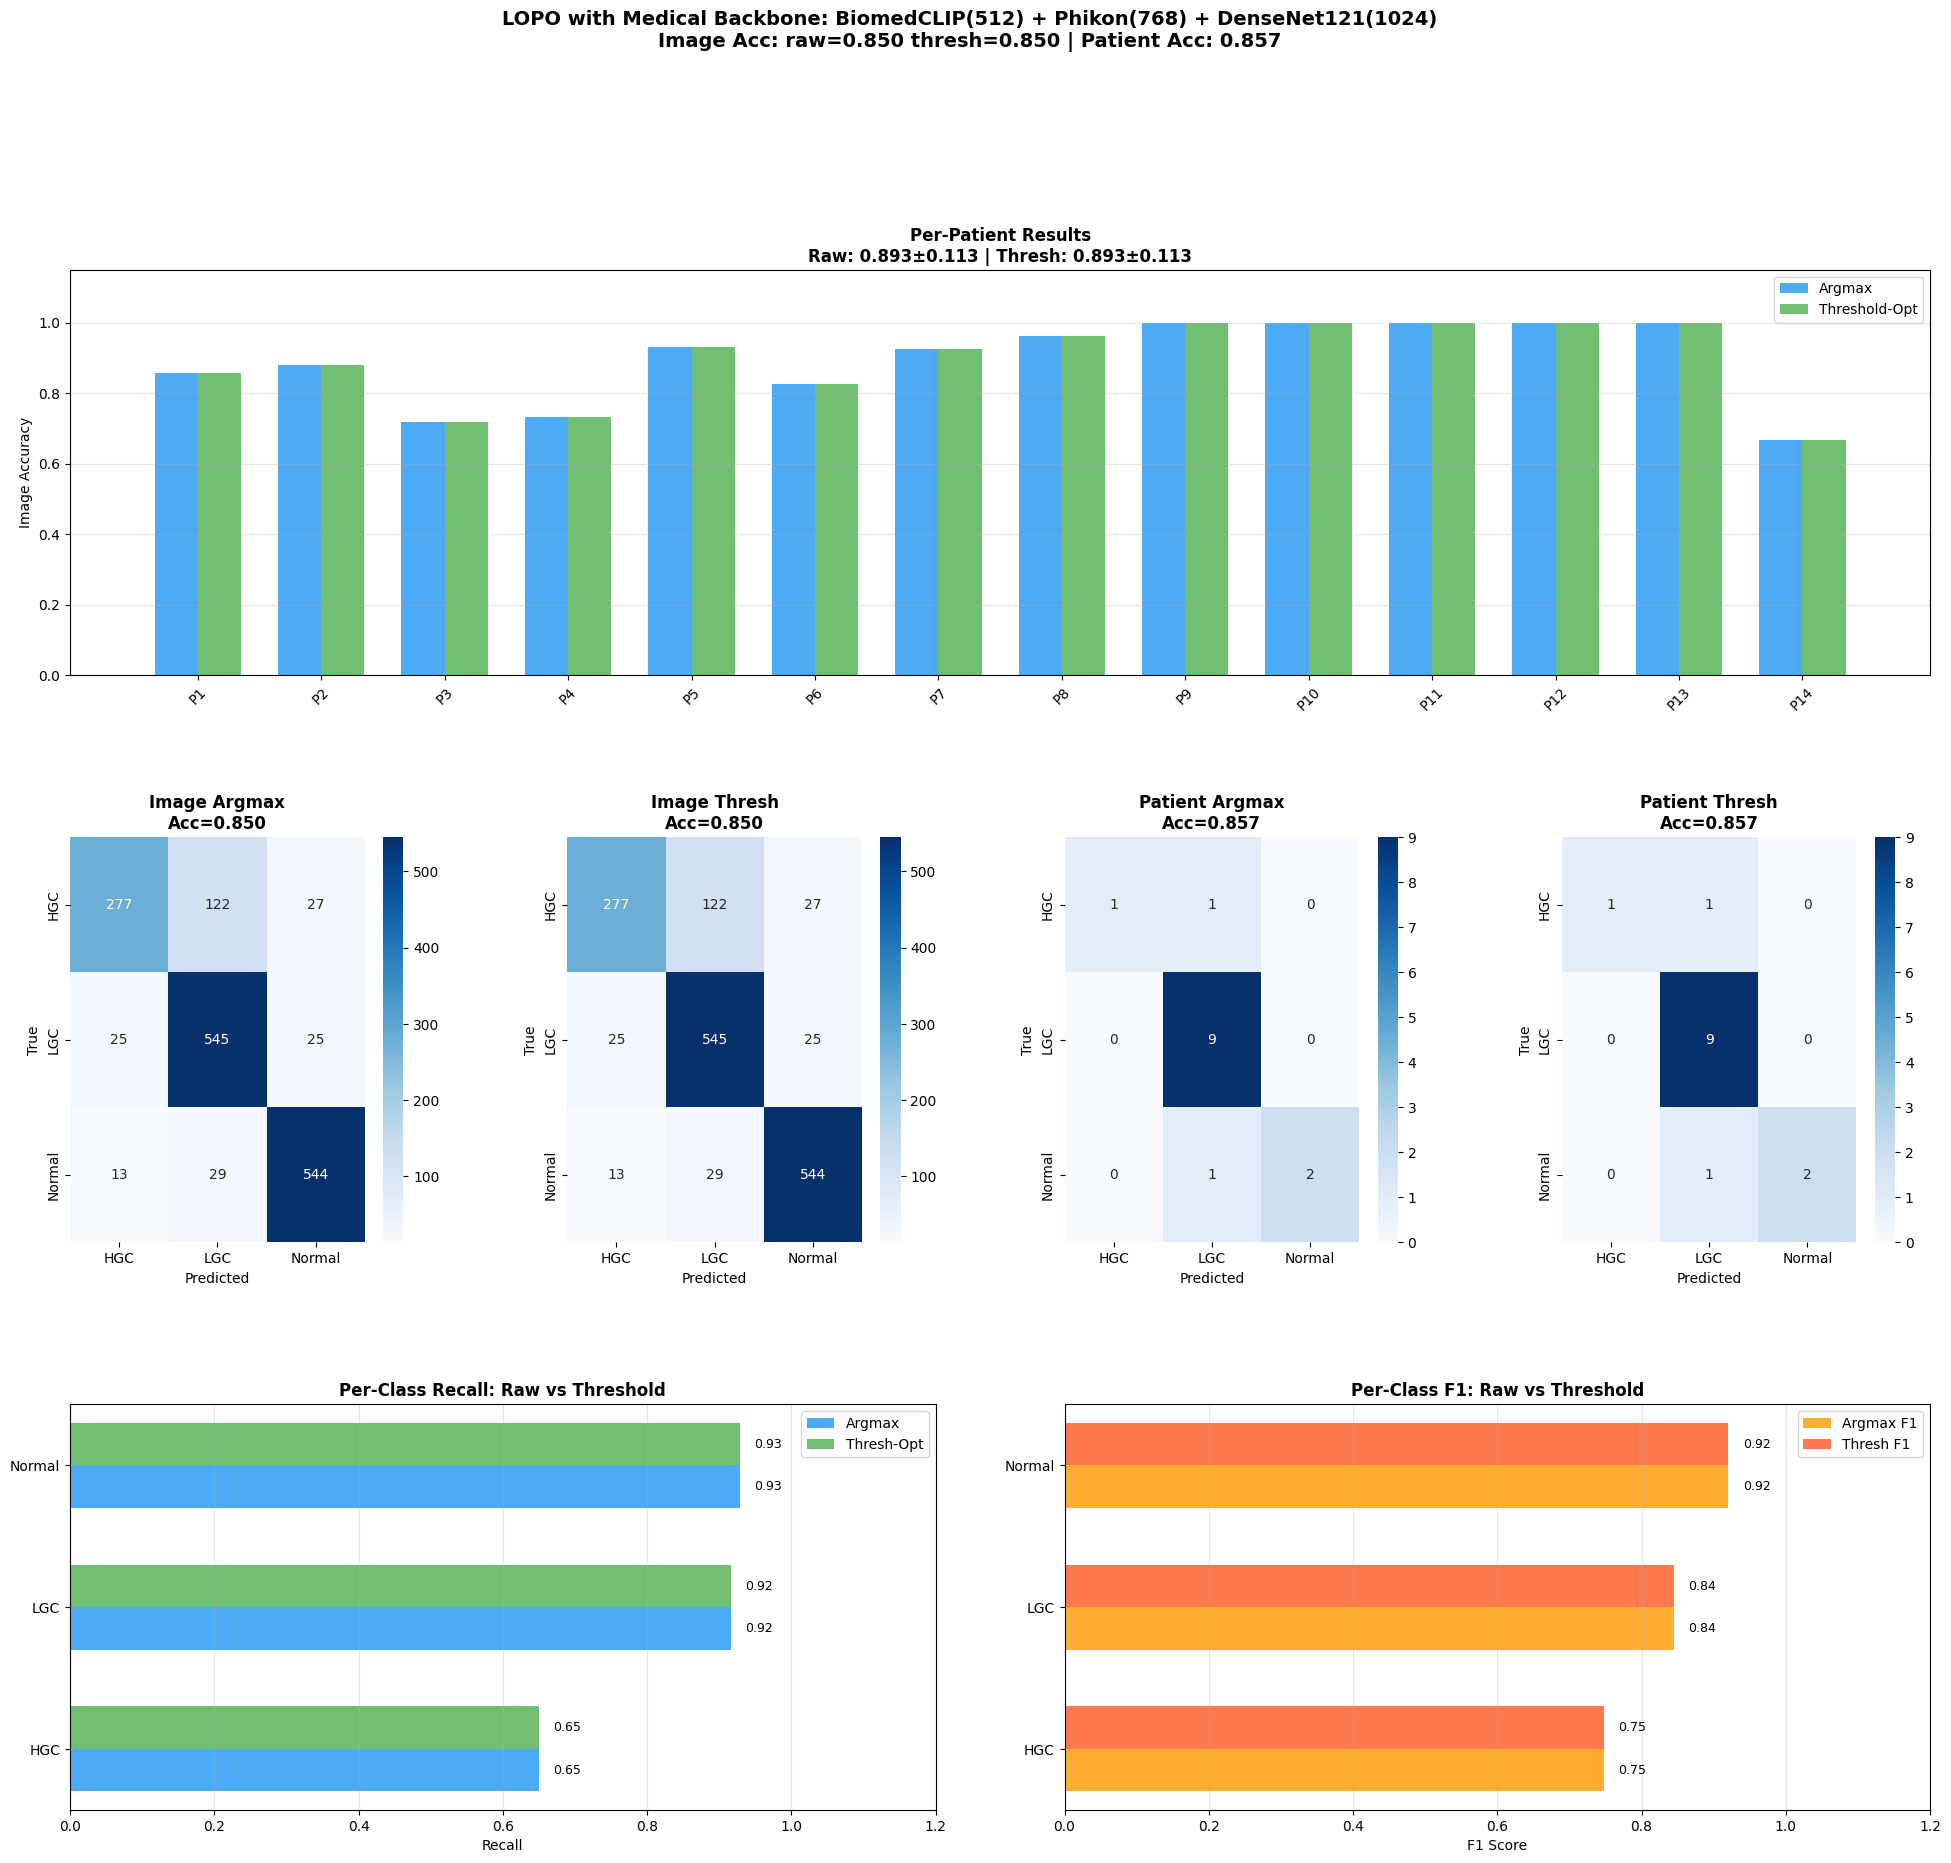

✓ Saved lopo_medical_results.png


In [14]:
# ============================================================
# CELL 14: VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(24, 20))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.35)

# ── Row 1: Per-patient accuracy (raw vs thresh) ─────────────
ax1 = fig.add_subplot(gs[0, :])
pids = [f"P{f['patient']}" for f in results['folds']]
ar   = [f['acc_raw'] for f in results['folds']]
at   = [f['acc_thresh'] for f in results['folds']]

x = np.arange(len(pids)); w = 0.35
ax1.bar(x - w/2, ar, w, color='#2196F3', alpha=0.8, label='Argmax')
ax1.bar(x + w/2, at, w, color='#4CAF50', alpha=0.8, label='Threshold-Opt')
ax1.set_ylabel('Image Accuracy')
ax1.set_title(
    f'Per-Patient Results\n'
    f'Raw: {results["img_raw"]["mean_pat_acc"]:.3f}±{results["img_raw"]["std_pat_acc"]:.3f} | '
    f'Thresh: {results["img_thresh"]["mean_pat_acc"]:.3f}±{results["img_thresh"]["std_pat_acc"]:.3f}',
    fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(pids, rotation=45)
ax1.set_ylim(0, 1.15)
ax1.grid(axis='y', alpha=0.3)
ax1.legend()

# ── Row 2: Confusion matrices (4 views) ─────────────────────
for col, (title, key) in enumerate([
    ("Image Argmax",   'img_raw'),
    ("Image Thresh",   'img_thresh'),
    ("Patient Argmax", 'pat_raw'),
    ("Patient Thresh", 'pat_thresh'),
]):
    ax = fig.add_subplot(gs[1, col])
    cm = np.array(results[key]['confusion'])
    if key.startswith('pat'):
        acc_val = results[key]['acc']
    else:
        acc_val = results[key]['overall_acc']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CFG.class_names, yticklabels=CFG.class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title}\nAcc={acc_val:.3f}', fontweight='bold')

# ── Row 3: Per-class recall comparison ───────────────────────
ax5 = fig.add_subplot(gs[2, :2])
cm_raw = np.array(results['img_raw']['confusion'])
cm_thr = np.array(results['img_thresh']['confusion'])
recall_raw = [cm_raw[i, i] / max(cm_raw[i].sum(), 1) for i in range(CFG.num_classes)]
recall_thr = [cm_thr[i, i] / max(cm_thr[i].sum(), 1) for i in range(CFG.num_classes)]

y = np.arange(CFG.num_classes); bw = 0.3
ax5.barh(y - bw/2, recall_raw, bw, color='#2196F3', alpha=0.8, label='Argmax')
ax5.barh(y + bw/2, recall_thr, bw, color='#4CAF50', alpha=0.8, label='Thresh-Opt')
for i in range(CFG.num_classes):
    ax5.text(recall_raw[i] + 0.02, i - bw/2, f'{recall_raw[i]:.2f}', va='center', fontsize=9)
    ax5.text(recall_thr[i] + 0.02, i + bw/2, f'{recall_thr[i]:.2f}', va='center', fontsize=9)
ax5.set_yticks(y)
ax5.set_yticklabels(CFG.class_names)
ax5.set_xlabel('Recall')
ax5.set_title('Per-Class Recall: Raw vs Threshold', fontweight='bold')
ax5.set_xlim(0, 1.2)
ax5.grid(axis='x', alpha=0.3)
ax5.legend()

# ── Row 3: F1 comparison ────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2:])
prec_raw = [cm_raw[i, i] / max(cm_raw[:, i].sum(), 1) for i in range(CFG.num_classes)]
prec_thr = [cm_thr[i, i] / max(cm_thr[:, i].sum(), 1) for i in range(CFG.num_classes)]
f1_raw = [2 * prec_raw[i] * recall_raw[i] / max(prec_raw[i] + recall_raw[i], 1e-8)
          for i in range(CFG.num_classes)]
f1_thr = [2 * prec_thr[i] * recall_thr[i] / max(prec_thr[i] + recall_thr[i], 1e-8)
          for i in range(CFG.num_classes)]

ax6.barh(y - bw/2, f1_raw, bw, color='#FF9800', alpha=0.8, label='Argmax F1')
ax6.barh(y + bw/2, f1_thr, bw, color='#FF5722', alpha=0.8, label='Thresh F1')
for i in range(CFG.num_classes):
    ax6.text(f1_raw[i] + 0.02, i - bw/2, f'{f1_raw[i]:.2f}', va='center', fontsize=9)
    ax6.text(f1_thr[i] + 0.02, i + bw/2, f'{f1_thr[i]:.2f}', va='center', fontsize=9)
ax6.set_yticks(y)
ax6.set_yticklabels(CFG.class_names)
ax6.set_xlabel('F1 Score')
ax6.set_title('Per-Class F1: Raw vs Threshold', fontweight='bold')
ax6.set_xlim(0, 1.2)
ax6.grid(axis='x', alpha=0.3)
ax6.legend()

fig.suptitle(
    f'LOPO with Medical Backbone: {backbone_desc}\n'
    f'Image Acc: raw={results["img_raw"]["overall_acc"]:.3f} '
    f'thresh={results["img_thresh"]["overall_acc"]:.3f} | '
    f'Patient Acc: {results["pat_thresh"]["acc"]:.3f}',
    fontsize=14, fontweight='bold', y=1.01
)
plt.savefig('lopo_medical_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved lopo_medical_results.png")

In [15]:
# ============================================================
# CELL 15: EXPORT RESULTS
# ============================================================

def to_ser(obj):
    if isinstance(obj, (np.integer,)):   return int(obj)
    if isinstance(obj, (np.floating,)):  return float(obj)
    if isinstance(obj, np.ndarray):      return obj.tolist()
    return obj

summary = {
    'pipeline':             f'Lab_Norm + MultiScale + {backbone_desc} + CLAM_medical',
    'evaluation':           'LOPO',
    'augmentation':         True,
    'backbone':             backbone_desc,
    'classes':              CFG.class_names,
    'n_patients':           N_PATIENTS,
    'total_original':       EXPECTED_TOTAL,
    'total_augmented':      len(aug_df),
    'results_img_raw':      results['img_raw'],
    'results_img_thresh':   results['img_thresh'],
    'results_pat_raw':      results['pat_raw'],
    'results_pat_thresh':   results['pat_thresh'],
    'fold_details':         results['folds'],
    'config': {
        'focal_gamma':          CFG.focal_gamma,
        'hgc_weight_boost':     CFG.hgc_weight_boost,
        'asymmetric_cost':      CFG.misclass_cost,
        'ordinal_loss_w':       CFG.ordinal_loss_w,
        'hier_loss_w':          CFG.hier_loss_w,
        'epochs':               CFG.epochs,
        'patience':             CFG.patience,
        'lr':                   CFG.lr,
        'n_ensemble':           CFG.n_ensemble,
        'balanced_sampling':    CFG.balanced_sampling,
        'mc_dropout':           CFG.use_mc_dropout,
        'tta_rounds':           CFG.tta_rounds,
        'threshold_opt':        CFG.optimize_thresholds,
        'recall_priority':      CFG.recall_priority,
        'total_runtime_min':    total_time / 60,
    }
}

with open('results_medical.json', 'w') as f:
    json.dump(summary, f, indent=2, default=to_ser)
print("✓ Saved results_medical.json")

# Per-patient CSV
rows = []
for f in results['folds']:
    rows.append({
        'patient':         f['patient'],
        'n_test':          f['n_test'],
        'acc_raw':         round(f['acc_raw'], 4),
        'acc_thresh':      round(f['acc_thresh'], 4),
        'bal_raw':         round(f['bal_raw'], 4),
        'bal_thresh':      round(f['bal_thresh'], 4),
        'pat_true':        idx_to_class[f['pat_true']],
        'pat_pred_raw':    idx_to_class[f['pat_pred_raw']],
        'pat_pred_thresh': idx_to_class[f['pat_pred_thresh']],
        'thresholds':      str(f['thresh']),
        'confidence':      round(f['conf'], 4),
        'n_aug':           f['n_aug'],
    })
pd.DataFrame(rows).to_csv('fold_results_medical.csv', index=False)
print("✓ Saved fold_results_medical.csv")

# Classification reports for all modes
for mode, key in [('img_raw', 'img_raw'), ('img_thresh', 'img_thresh'),
                  ('pat_raw', 'pat_raw'), ('pat_thresh', 'pat_thresh')]:
    r = results[key]
    with open(f'report_medical_{mode}.txt', 'w') as f:
        f.write(f"MODE: {mode}\nBACKBONE: {backbone_desc}\n{'='*50}\n\n")
        f.write(classification_report(r['y_true'], r['y_pred'],
                target_names=CFG.class_names, zero_division=0))
    print(f"✓ Saved report_medical_{mode}.txt")

print(f"\n{'='*60}")
print(f"  EXPERIMENT COMPLETE — MEDICAL BACKBONE")
print(f"{'='*60}")
print(f"\n  Backbone: {backbone_desc}")
print(f"\n  IMAGE-LEVEL (argmax):")
print(f"    Mean Patient Acc : {results['img_raw']['mean_pat_acc']:.4f}")
print(f"    Overall Acc      : {results['img_raw']['overall_acc']:.4f}")
print(f"    Overall Balanced : {results['img_raw']['overall_bal']:.4f}")
print(f"\n  IMAGE-LEVEL (threshold-optimized):")
print(f"    Mean Patient Acc : {results['img_thresh']['mean_pat_acc']:.4f}")
print(f"    Overall Acc      : {results['img_thresh']['overall_acc']:.4f}")
print(f"    Overall Balanced : {results['img_thresh']['overall_bal']:.4f}")
print(f"\n  PATIENT-LEVEL (threshold-optimized):")
print(f"    Accuracy         : {results['pat_thresh']['acc']:.4f}")
print(f"    Balanced         : {results['pat_thresh']['bal']:.4f}")
print(f"\n  Runtime: {total_time/60:.1f} min ({total_time/3600:.1f} hours)")
print(f"{'='*60}\n")

✓ Saved results_medical.json
✓ Saved fold_results_medical.csv
✓ Saved report_medical_img_raw.txt
✓ Saved report_medical_img_thresh.txt
✓ Saved report_medical_pat_raw.txt
✓ Saved report_medical_pat_thresh.txt

  EXPERIMENT COMPLETE — MEDICAL BACKBONE

  Backbone: BiomedCLIP(512) + Phikon(768) + DenseNet121(1024)

  IMAGE-LEVEL (argmax):
    Mean Patient Acc : 0.8928
    Overall Acc      : 0.8500
    Overall Balanced : 0.8315

  IMAGE-LEVEL (threshold-optimized):
    Mean Patient Acc : 0.8928
    Overall Acc      : 0.8500
    Overall Balanced : 0.8315

  PATIENT-LEVEL (threshold-optimized):
    Accuracy         : 0.8571
    Balanced         : 0.7222

  Runtime: 1141.0 min (19.0 hours)

